# Complete Model Walkthrough: From Raw Data to Inference
This notebook covers the entire lifecycle of our Named Entity Recognition (NER) model for Resume Parsing.

**Steps covered:**
1. Data Preprocessing
2. Base Model Evaluation (Before Training)
3. Fine-Tuning (Training)
4. Post-Training Evaluation
5. Visualization of Training Metrics
6. Real-World Testing

In [1]:
import json
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer
import evaluate

import warnings
warnings.filterwarnings('ignore')

c:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## 1. Data Preprocessing
We load our raw annotated resume dataset and align character-level annotations to token-level labels.

In [2]:
LABEL_LIST = ["O", "B-SKILL", "I-SKILL", "B-EDU", "I-EDU", "B-EXP", "I-EXP"]
LABEL_TO_ID = {label: i for i, label in enumerate(LABEL_LIST)}
ID_TO_LABEL = {i: label for i, label in enumerate(LABEL_LIST)}

MAP_LABELS = {
    "Skills": "SKILL",
    "Degree": "EDU",
    "College Name": "EDU",
    "Companies worked at": "EXP",
    "Designation": "EXP"
}

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def load_and_preprocess_data():
    examples = []
    dataset_paths = [
        Path(r"c:\Users\Dell\Desktop\Cloud Projecct\d\new dataset\Entity Recognition in Resumes.json"),
        Path(r"c:\Users\Dell\Desktop\Cloud Projecct\d\new dataset\traindata.json")
    ]

    for path in dataset_paths:
        if not path.exists(): continue
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                if not line.strip(): continue
                try: data = json.loads(line)
                except: continue
                    
                text = data["content"]
                annotations = data.get("annotation", [])
                
                char_labels = ["O"] * len(text)
                for ann in annotations:
                    if not ann.get("label"): continue
                    label_name = ann["label"][0]
                    if label_name not in MAP_LABELS: continue
                    entity_type = MAP_LABELS[label_name]
                    
                    for point in ann["points"]:
                        start, end = max(0, point["start"]), min(len(text), point["end"])
                        if start < end:
                            char_labels[start] = f"B-{entity_type}"
                            for i in range(start + 1, end):
                                char_labels[i] = f"I-{entity_type}"
                                
                tokenized = tokenizer(text, return_offsets_mapping=True, truncation=True, max_length=256, padding="max_length")
                offsets = tokenized["offset_mapping"]
                
                labels = []
                for tok_start, tok_end in offsets:
                    if tok_start == 0 and tok_end == 0:
                        labels.append(-100)
                        continue
                        
                    covered_labels = char_labels[tok_start:tok_end]
                    b_tags = [tag for tag in covered_labels if tag.startswith("B-")]
                    i_tags = [tag for tag in covered_labels if tag.startswith("I-")]
                    
                    if b_tags: labels.append(LABEL_TO_ID[b_tags[0]])
                    elif i_tags: labels.append(LABEL_TO_ID[i_tags[0]])
                    else: labels.append(LABEL_TO_ID["O"])
                        
                examples.append({"input_ids": tokenized["input_ids"], "attention_mask": tokenized["attention_mask"], "labels": labels})
                
    return Dataset.from_list(examples)

dataset = load_and_preprocess_data()
# Using a small subset so this walkthrough notebook executes quickly in demonstrations
small_dataset = dataset.select(range(min(150, len(dataset))))
dataset_split = small_dataset.train_test_split(test_size=0.2)
print(f"Loaded dataset! Train size: {len(dataset_split['train'])}, Test size: {len(dataset_split['test'])}")

Loaded dataset! Train size: 120, Test size: 30


## 2. Evaluation BEFORE Fine-Tuning
Evaluating the untaught base model (`distilbert-base-uncased`) to establish a baseline.

In [3]:
base_model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(LABEL_LIST),
    id2label=ID_TO_LABEL,
    label2id=LABEL_TO_ID,
    ignore_mismatched_sizes=True
)

seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_predictions = [
        [LABEL_LIST[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [LABEL_LIST[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

pre_trainer = Trainer(model=base_model, eval_dataset=dataset_split["test"], compute_metrics=compute_metrics)
pre_eval_results = pre_trainer.evaluate()

print("\n--- PRE-TRAINING METRICS ---")
print(f"Precision: {pre_eval_results['eval_precision']:.4f}")
print(f"Recall:    {pre_eval_results['eval_recall']:.4f}")
print(f"F1-Score:  {pre_eval_results['eval_f1']:.4f}")

Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- PRE-TRAINING METRICS ---
Precision: 0.0026
Recall:    0.0822
F1-Score:  0.0051


## 3. Fine-Tuning (Training)
Training the model on our parsed CVs. For this demonstration walkthrough, we use a quick 3 epochs.

In [4]:
training_args = TrainingArguments(
    output_dir="./walkthrough_results",
    eval_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    save_total_limit=1,
    logging_steps=5,
)

trainer = Trainer(
    model=base_model,
    args=training_args,
    train_dataset=dataset_split["train"],
    eval_dataset=dataset_split["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

print("Starting Training...")
train_results = trainer.train()
print("Training Complete!")

Starting Training...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.470400,0.500862,0.000000,0.000000,0.000000,0.881289
2,0.255100,0.414968,0.236842,0.123288,0.162162,0.894479
3,0.219000,0.313385,0.139860,0.136986,0.138408,0.899918
4,0.121600,0.235259,0.235602,0.308219,0.267062,0.913244
5,0.152300,0.281899,0.236967,0.342466,0.280112,0.915692
6,0.101500,0.337310,0.294444,0.363014,0.325153,0.909165
7,0.074500,0.302567,0.305263,0.397260,0.345238,0.918276
8,0.077500,0.284832,0.307263,0.376712,0.338462,0.921947
9,0.072400,0.278650,0.287129,0.397260,0.333333,0.922219
10,0.065200,0.320233,0.317460,0.410959,0.358209,0.919228


Training Complete!


## 4. Evaluation AFTER Fine-Tuning
Re-evaluating the model on the exact same test set to demonstrate learning improvement.

In [5]:
post_eval_results = trainer.evaluate()

print("\n--- POST-TRAINING METRICS ---")
print(f"Precision: {post_eval_results['eval_precision']:.4f}")
print(f"Recall:    {post_eval_results['eval_recall']:.4f}")
print(f"F1-Score:  {post_eval_results['eval_f1']:.4f}")

f1_improvement = post_eval_results['eval_f1'] - pre_eval_results['eval_f1']
print(f"\nTotal F1 Improvement: +{f1_improvement:.4f}")


--- POST-TRAINING METRICS ---
Precision: 0.3175
Recall:    0.4110
F1-Score:  0.3582

Total F1 Improvement: +0.3531


## 5. Visualization of Training Metrics
Plotting the training loss to visually confirm the model is learning successfully.

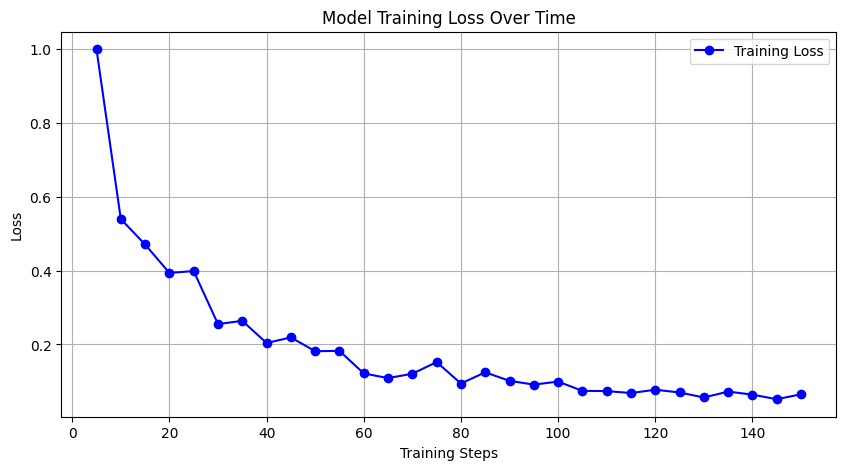

In [6]:
history = trainer.state.log_history
loss_values = [h["loss"] for h in history if "loss" in h]
steps = [h["step"] for h in history if "loss" in h]

plt.figure(figsize=(10, 5))
plt.plot(steps, loss_values, marker='o', linestyle='-', color='b', label='Training Loss')
plt.title('Model Training Loss Over Time')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 6. Real-World Testing & Visualization
Finally, we pass a raw, completely unseen resume paragraph to our newly trained model and visualize what it extracts.

In [7]:
test_resume = """
Ahmed Hassan
Education: B.Sc. in Computer Science, Cairo University
Experience: Software Engineer at Microsoft (2020-2023). Developed microservices.
Skills: Highly proficient in Python, SQL, Docker, and Machine Learning algorithms.
"""

inputs = tokenizer(test_resume, return_tensors="pt", truncation=True, max_length=256)
device = "cuda" if torch.cuda.is_available() else "cpu"
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = base_model(**inputs)

predictions = torch.argmax(outputs.logits, dim=2)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
pred_labels = [base_model.config.id2label[p.item()] for p in predictions[0]]

extracted_data = {"SKILL": [], "EDU": [], "EXP": []}

current_entity = []
current_type = None

for token, label in zip(tokens, pred_labels):
    if token in ["[CLS]", "[SEP]", "[PAD]"]: continue
        
    if label != "O":
        entity_type = label.split("-")[1]
        clean_token = token.replace("##", "")
        
        if label.startswith("B-"):
            if current_entity:
                extracted_data[current_type].append("".join(current_entity))
            current_entity = [clean_token] if not token.startswith("##") else [" " + clean_token]
            current_type = entity_type
        elif label.startswith("I-") and current_type == entity_type:
            if token.startswith("##"):
                current_entity.append(clean_token)
            else:
                current_entity.append(" " + clean_token)
    else:
        if current_entity:
            extracted_data[current_type].append("".join(current_entity))
            current_entity = []
            current_type = None

if current_entity:
    extracted_data[current_type].append("".join(current_entity))

print("RAW RESUME TEXT:")
print("-" * 50)
print(test_resume.strip())
print("\nAI EXTRACTED ENTITIES:")
print("-" * 50)
for category, items in extracted_data.items():
    print(f"{category}: {', '.join(set(items)) if items else 'None found'}")

RAW RESUME TEXT:
--------------------------------------------------
Ahmed Hassan
Education: B.Sc. in Computer Science, Cairo University
Experience: Software Engineer at Microsoft (2020-2023). Developed microservices.
Skills: Highly proficient in Python, SQL, Docker, and Machine Learning algorithms.

AI EXTRACTED ENTITIES:
--------------------------------------------------
SKILL: None found
EDU: b . sc . in computer science
EXP: software engineer, microsoft
